In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

df = pd.read_csv("../data/raw/dt_simulated_weekly.csv")
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True) 

# Define your column groups
MEDIA_SPEND_COLS = ['tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S']
TARGET = 'revenue'
DATE   = 'DATE'

In [27]:
# ── Summary statistics ───────────────────────────────────────
print("DATASET SUMMARY")
print(f"Weeks: {df.shape[0]}")
print(f"Date range: {df[DATE].min().date()} to {df[DATE].max().date()}")

df[['revenue', 'tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S', 'facebook_I', 'search_clicks_P', 
    'competitor_sales_B', 'newsletter']].describe().map(lambda x: f"{x:,.0f}")


DATASET SUMMARY
Weeks: 208
Date range: 2015-11-23 to 2019-11-11


,revenue,tv_S,ooh_S,print_S,facebook_S,search_S,facebook_I,search_clicks_P,competitor_sales_B,newsletter
count,208,208,208,208,208,208,208,208,208,208
mean,"1,822,143","14,844","43,218","3,729","2,146","5,916","8,153,415","16,945","5,538,025","22,387"
std,"716,229","28,558","83,991","6,483","3,160","4,703","11,699,127","13,614","2,077,192","19,104"
min,"672,250",0,0,0,0,0,0,0,"2,240,235",301
25%,"1,165,211",0,0,0,0,"2,353",0,"6,281","3,589,581","9,010"
50%,"1,874,514",0,0,0,0,"4,807",0,"14,265","5,538,524","19,402"
75%,"2,378,407","18,407","50,858","4,768","3,623","8,537","13,737,419","25,237","7,311,814","27,546"
max,"3,827,520","158,047","500,362","31,922","15,400","17,880","59,432,758","52,188","9,984,742","96,236"


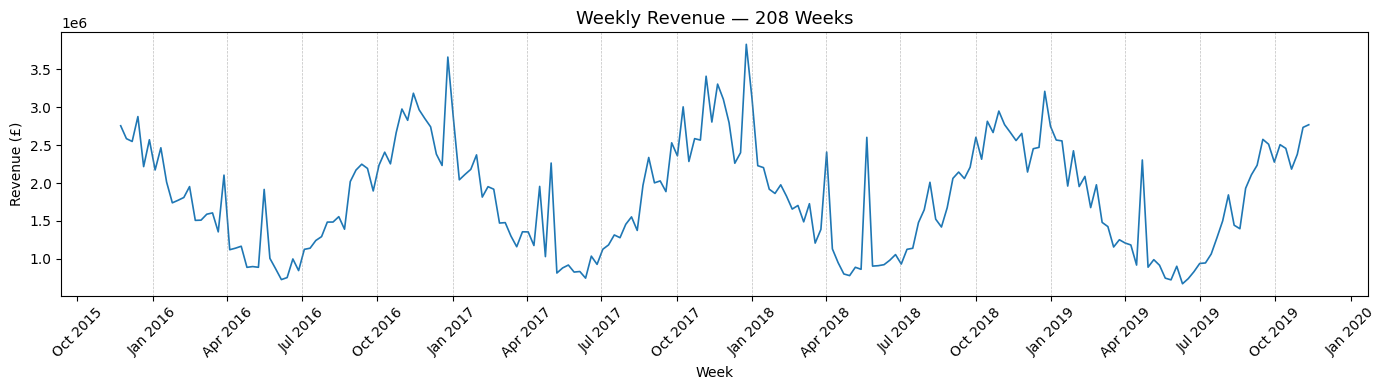

In [28]:
# ── Revenue over time ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df[DATE], df[TARGET], linewidth=1.2, color='#1f77b4')
ax.set_title("Weekly Revenue — 208 Weeks", fontsize=13)
ax.set_xlabel("Week")
ax.set_ylabel("Revenue (£)")

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

import pandas as pd
quarter_starts = pd.date_range(start=df[DATE].min(), end=df[DATE].max(), freq='QS')
for qdate in quarter_starts:
    ax.axvline(qdate, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../plots/eda_plots/revenue_timeseries.png", dpi=150, bbox_inches='tight')
plt.show()

In [29]:
OUTLIER_COLS = ['revenue', 'tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S',
                'facebook_I', 'search_clicks_P', 'competitor_sales_B', 'newsletter']

outlier_rows = []

for col in OUTLIER_COLS:
    series = df[col]
    mean, std = series.mean(), series.std(ddof=0)
    z_scores = (series - mean) / std
    flagged = df[z_scores.abs() >= 3][[DATE, col, 'holiday', 'events', 'month']].copy()
    flagged['column'] = col
    flagged['z_score'] = z_scores[flagged.index].round(2)
    outlier_rows.append(flagged.rename(columns={col: 'value'}))

all_outliers = pd.concat(outlier_rows, ignore_index=True)[[DATE, 'column', 'value', 'z_score', 'holiday', 'events', 'month']]

if len(all_outliers) > 0:
    display(all_outliers.sort_values('z_score', key=abs, ascending=False))
else:
    print("No outliers found across any column (|z| >= 3).")

print(f"\nTotal flagged: {len(all_outliers)} rows across {all_outliers['column'].nunique() if len(all_outliers) > 0 else 0} columns")

print("\nColumns with outliers:")
for col, count in all_outliers.groupby('column').size().sort_values(ascending=False).items():
    print(f"  {col}: {count} outlier{'s' if count > 1 else ''}")

,DATE,column,value,z_score,holiday,events,month
9,2017-04-10,ooh_S,5.003616e+05,5.46,Good Friday,na,April
5,2018-12-24,tv_S,1.580466e+05,5.03,"Christmas Day, Second Day of Christmas",na,December
4,2018-10-01,tv_S,1.567034e+05,4.98,German Unity Day,na,October
8,2017-01-02,ooh_S,4.536960e+05,4.90,holiday free week,na,January
0,2016-10-03,tv_S,1.445366e+05,4.55,German Unity Day,na,October
28,2019-08-05,facebook_I,5.943276e+07,4.39,holiday free week,na,August
14,2015-12-28,print_S,3.192231e+04,4.36,New Year's Day,na,December
22,2019-08-05,facebook_S,1.540039e+04,4.20,holiday free week,na,August
31,2019-01-07,newsletter,9.623600e+04,3.87,holiday free week,na,January
17,2017-01-02,print_S,2.799813e+04,3.75,holiday free week,na,January



Total flagged: 34 rows across 6 columns

Columns with outliers:
  ooh_S: 8 outliers
  facebook_S: 6 outliers
  tv_S: 6 outliers
  facebook_I: 5 outliers
  print_S: 5 outliers
  newsletter: 4 outliers


### Outlier Investigations
Three rows flagged for closer inspection: OOH Jan 2017 (no context, 10x mean), OOH Apr 2017 (Good Friday, highest z-score), Facebook Aug 2019 (largest Facebook burst with no holiday or event).

In [30]:
# Investigation 1: OOH Jan 2017 — £453K with no holiday or event
cols = [DATE, 'ooh_S', 'revenue', 'holiday', 'events']
window = df[(df[DATE] >= '2016-11-01') & (df[DATE] <= '2017-03-31')][cols].copy()
window['ooh_S'] = window['ooh_S'].apply(lambda x: f"£{x:,.0f}")
window['revenue'] = window['revenue'].apply(lambda x: f"£{x:,.0f}")
display(window.reset_index(drop=True))

,DATE,ooh_S,revenue,holiday,events
0,2016-11-07,"£142,602","£2,826,128",holiday free week,na
1,2016-11-14,£0,"£3,182,900",holiday free week,na
2,2016-11-21,"£145,018","£2,964,697",holiday free week,na
3,2016-11-28,£0,"£2,848,525",holiday free week,na
4,2016-12-05,"£239,081","£2,740,160",holiday free week,na
5,2016-12-12,£0,"£2,380,508",holiday free week,na
6,2016-12-19,"£334,920","£2,230,915",Christmas Day,na
7,2016-12-26,£0,"£3,659,425","Second Day of Christmas, New Year's Day",na
8,2017-01-02,"£453,696","£2,827,008",holiday free week,na
9,2017-01-09,£0,"£2,042,143",holiday free week,na


In [31]:
# Investigation 2: OOH Apr 2017 — £500K on Good Friday, highest z-score in dataset
cols = [DATE, 'ooh_S', 'revenue', 'holiday', 'events']
window = df[(df[DATE] >= '2017-03-01') & (df[DATE] <= '2017-05-31')][cols].copy()
window['ooh_S'] = window['ooh_S'].apply(lambda x: f"£{x:,.0f}")
window['revenue'] = window['revenue'].apply(lambda x: f"£{x:,.0f}")
display(window.reset_index(drop=True))

,DATE,ooh_S,revenue,holiday,events
0,2017-03-06,£0,"£1,477,865",holiday free week,na
1,2017-03-13,£0,"£1,300,167",holiday free week,na
2,2017-03-20,£0,"£1,160,205",holiday free week,na
3,2017-03-27,"£24,476","£1,356,872",holiday free week,na
4,2017-04-03,£0,"£1,355,833",holiday free week,na
5,2017-04-10,"£500,362","£1,176,267",Good Friday,na
6,2017-04-17,£0,"£1,955,282",Easter Monday,na
7,2017-04-24,"£296,155","£1,029,928",holiday free week,na
8,2017-05-01,£0,"£2,263,143",Labor Day,na
9,2017-05-08,"£306,346","£813,772",holiday free week,na


In [32]:
# Investigation 3: Facebook Aug 2019 — highest Facebook burst, no holiday or event
cols = [DATE, 'facebook_S', 'facebook_I', 'revenue', 'holiday', 'events']
window = df[(df[DATE] >= '2019-06-01') & (df[DATE] <= '2019-10-31')][cols].copy()
window['facebook_S'] = window['facebook_S'].apply(lambda x: f"£{x:,.0f}")
window['facebook_I'] = window['facebook_I'].apply(lambda x: f"{x:,.0f}")
window['revenue'] = window['revenue'].apply(lambda x: f"£{x:,.0f}")
display(window.reset_index(drop=True))

,DATE,facebook_S,facebook_I,revenue,holiday,events
0,2019-06-03,£0,0,"£903,125",holiday free week,na
1,2019-06-10,£50,"1,303,103","£672,250",Whit Monday,na
2,2019-06-17,£0,0,"£739,783",holiday free week,na
3,2019-06-24,£0,0,"£831,833",holiday free week,na
4,2019-07-01,£0,0,"£939,897",holiday free week,na
5,2019-07-08,£0,0,"£946,510",holiday free week,na
6,2019-07-15,£0,0,"£1,063,913",holiday free week,na
7,2019-07-22,"£2,860","9,985,410","£1,278,223",holiday free week,na
8,2019-07-29,£0,0,"£1,500,828",holiday free week,na
9,2019-08-05,"£15,400","59,432,758","£1,843,118",holiday free week,na


The media spend and impression columns had statistical outliers, but each could be explained by seasonal campaign bursts, holiday timing, or the lag between advertising spend and revenue — none required data correction.

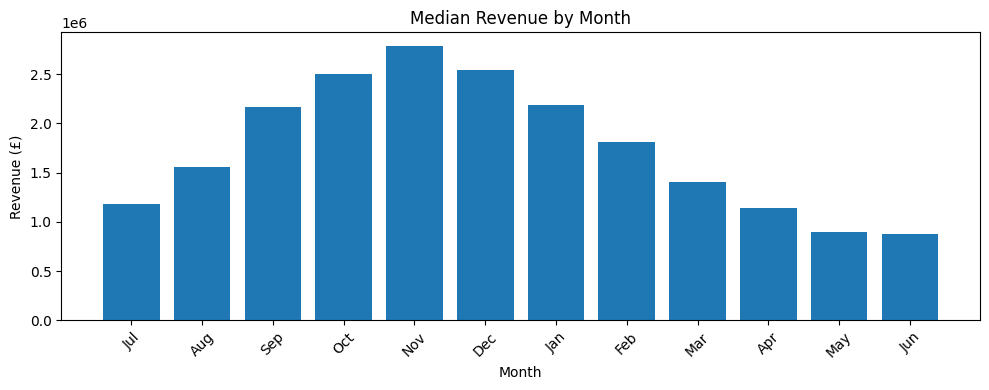

In [33]:
month_order = ['July','August','September','October','November','December',
               'January','February','March','April','May','June']

monthly = df.groupby('month')[TARGET].median().reindex(month_order)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(12), monthly.values, color='#1f77b4')
ax.set_title("Median Revenue by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in month_order], rotation=45)

plt.tight_layout()
plt.savefig("../plots/eda_plots/median_revenue_by_month.png", dpi=150, bbox_inches='tight')
plt.show()

There are two periods of significant revenue spikes in the data:

1. **Early Q4 to Early Q1:** A large, and well sustained peak builds from October through to the new year, confirmed by the Median Revenue by Month plot where November is the highest month on record.

2. **Late Q1 to Mid Q2:** A smaller spike consistently appears between late March and June, driven by the spring holiday calendar as you'd see explored below.

You can see the Late Q1 to Mid Q2 spike well defined in the Median Revenue by Month as revenue rises steadily from July, peaks around Q4, then declines into the new year. But see from our weekly revenue plot that as it drops off, a secondary spike interrupts the decline around Q2 before revenue hits its worst performance of the entire year in June.

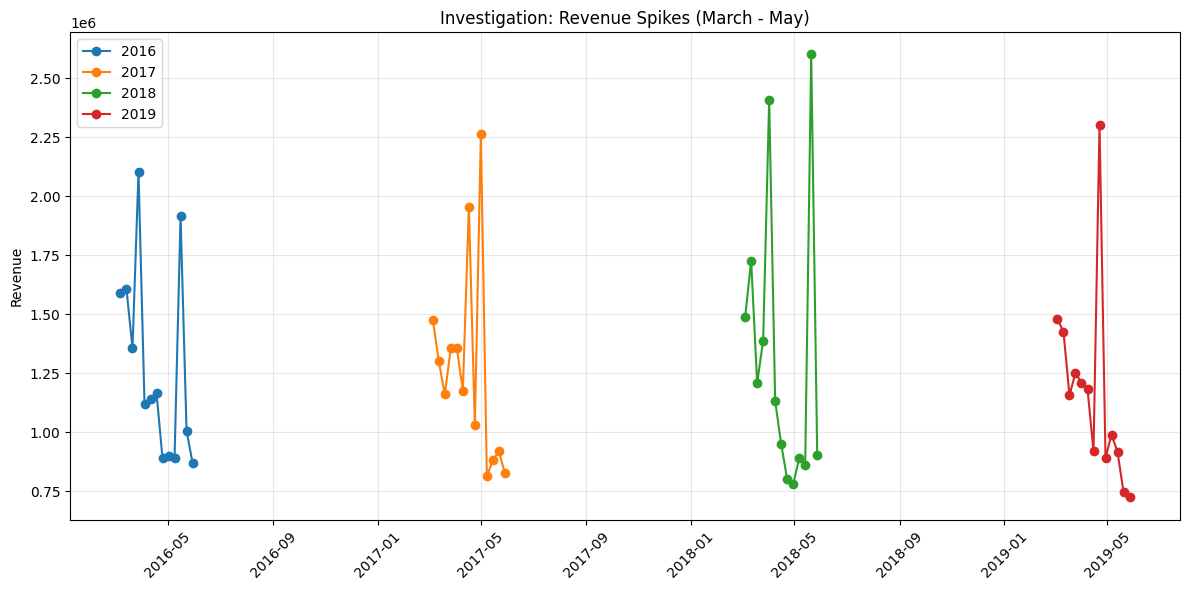

In [34]:
df['DATE'] = pd.to_datetime(df['DATE'])
filtered_df = df[df['DATE'].dt.month.isin([3, 4, 5])]

plt.figure(figsize=(12, 6))
for year in filtered_df['DATE'].dt.year.unique():
    year_data = filtered_df[filtered_df['DATE'].dt.year == year].sort_values('DATE')
    plt.plot(year_data['DATE'], year_data['revenue'], marker='o', label=str(year))

plt.title('Investigation: Revenue Spikes (March - May)')
plt.ylabel('Revenue')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../plots/eda_plots/revenue_spikes_mar_may.png", dpi=150, bbox_inches='tight')
plt.show()

I extracted the March to May window across all four years (2016-2019) and plotted 
revenue over time to investigate two consistent spikes visible in the full dataset.

```python
spike_weeks = df[(df['DATE'] >= '2016-03-01') & (df['DATE'] <= '2016-05-31')]
spike_weeks[['DATE', 'revenue', 'holiday', 'is_holiday', 'competitor_sales_B', 'events'] + MEDIA_SPEND_COLS]
```

Here's a brief picture of what I discovered:

**Spike 1:** Easter Monday lands between late March and late April depending on the 
year (it's a movable feast). Revenue consistently jumps to between £1.95M and £2.41M 
that week, up from a baseline of around £800K-£1.2M. The clearest evidence of a pure 
holiday effect is Easter Monday 2018: £2.41M with zero media spend across TV, OOH, 
Facebook, and Print. 

**Spike 2:** Late May holiday is driven by either Whit Monday or Labor Day, depending 
on the year. The largest spike in the entire Q2 dataset is Whit Monday 2018 at £2.6M, 
which also had `event1` flagged that week. The two biggest spikes across both categories 
(2018 Whit Monday and 2019 Easter Monday) both coincided with a company event, 
suggesting events act as a multiplier on top of the holiday effect rather than a 
standalone driver.

To conclude, the spikes we see from March to May are mostly driven by holidays, although ds and events definitely give things a solid extra push, especially in 2018 and 2019, where the largest peaks coincide with both a holiday and an event. 

With this in mind, it is important to include holidays and events as features in the model to isolate their effect on revenue. It is equally important to apply adstock and Hill transformations to the media channels, as we have seen, they don't always take effect in the week they are applied. 

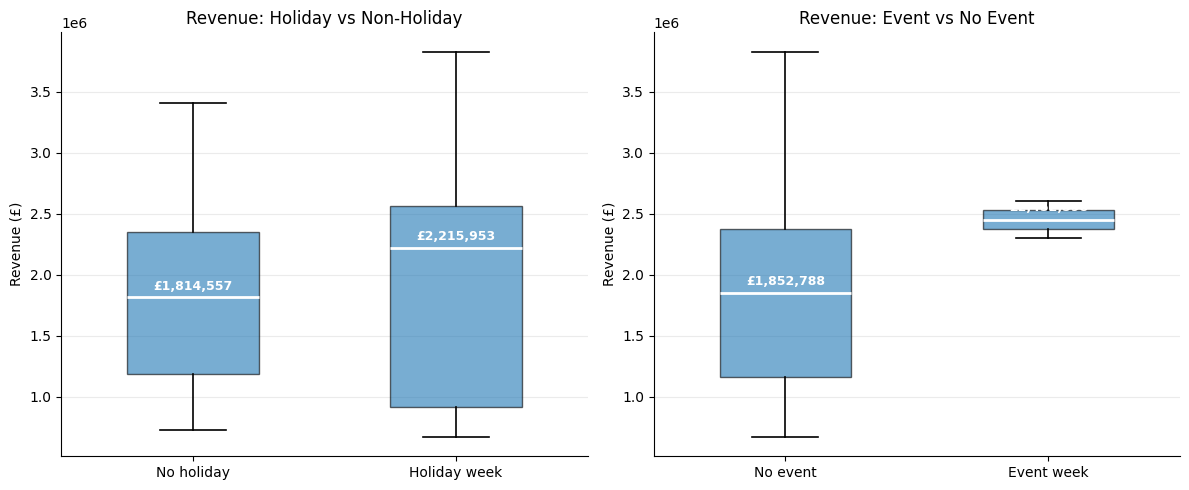

Holiday effect:
               median       mean  count
is_holiday                             
0           1814557.0  1802942.0    175
1           2215953.0  1923967.0     33

Event effect:
              median       mean  count
has_event                             
0          1852788.0  1816022.0    206
1          2452598.0  2452598.0      2


In [35]:
df['has_event'] = (df['events'].notna() & (df['events'] != 'na')).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (group_col, labels, title) in zip(axes, [
    ('is_holiday', {0: 'No holiday', 1: 'Holiday week'}, 'Revenue: Holiday vs Non-Holiday'),
    ('has_event', {0: 'No event', 1: 'Event week'}, 'Revenue: Event vs No Event'),
]):
    groups = [df.loc[df[group_col] == k, 'revenue'] for k in sorted(labels)]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor='#1f77b4', alpha=0.6),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))
    ax.set_xticklabels([labels[k] for k in sorted(labels)])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Revenue (£)')
    ax.grid(True, axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for i, (k, label) in enumerate(sorted(labels.items()), start=1):
        median = df.loc[df[group_col] == k, 'revenue'].median()
        ax.text(i, median * 1.02, f'£{median:,.0f}', ha='center', va='bottom', fontsize=9, color='white',
                fontweight='bold')

plt.tight_layout()
plt.savefig("../plots/eda_plots/holiday_event_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

print("Holiday effect:")
print(df.groupby('is_holiday')['revenue'].agg(['median', 'mean', 'count']).round(0))
print("\nEvent effect:")
print(df.groupby('has_event')['revenue'].agg(['median', 'mean', 'count']).round(0))

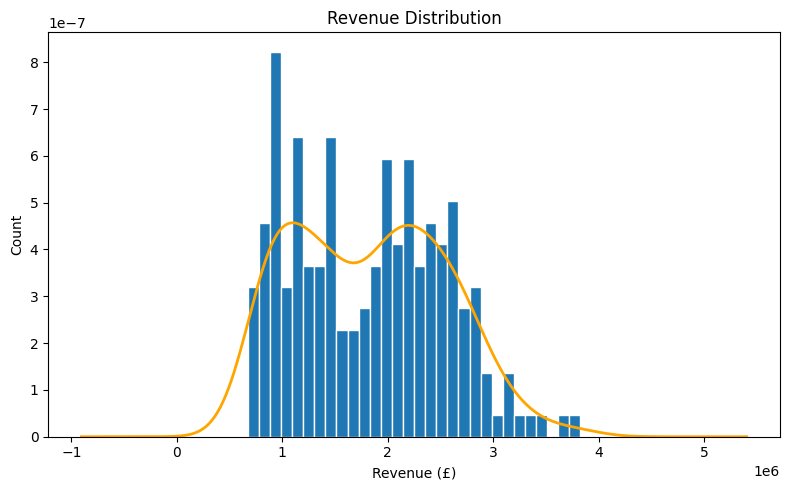

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df[TARGET], bins=30, color='#1f77b4', edgecolor='white', density=True)
df[TARGET].plot.kde(ax=ax, color='orange', linewidth=2)
ax.set_title("Revenue Distribution")
ax.set_xlabel("Revenue (£)")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("../plots/eda_plots/revenue_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

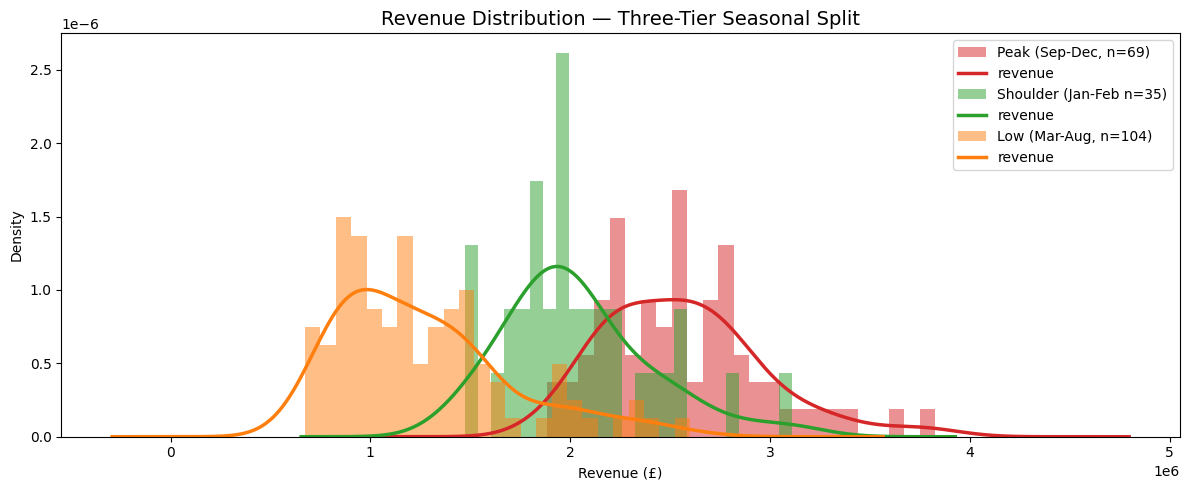

High Season Median: £2,547,387  | High Season Mean: £2,561,787
Shoulder Median:    £1,959,707  | Shoulder Mean:    £2,037,455
Low Season Median:  £1,163,542  | Low Season Mean:  £1,258,956


In [37]:
fig, ax = plt.subplots(figsize=(12, 5))

high_mask = df['DATE'].dt.month.isin([9, 10, 11, 12])
low_mask  = df['DATE'].dt.month.isin([3, 4, 5, 6, 7, 8])
shld_mask = df['DATE'].dt.month.isin([1, 2])

high_rev = df.loc[high_mask, TARGET]
low_rev  = df.loc[low_mask,  TARGET]
shld_rev = df.loc[shld_mask, TARGET]

ax.hist(high_rev, bins=25, color='#d62728', alpha=0.5, density=True, label=f'Peak (Sep-Dec, n={len(high_rev)})')
high_rev.plot.kde(ax=ax, color='#d62728', linewidth=2.5)

ax.hist(shld_rev, bins=25, color='#2ca02c', alpha=0.5, density=True, label=f'Shoulder (Jan-Feb n={len(shld_rev)})')
shld_rev.plot.kde(ax=ax, color='#2ca02c', linewidth=2.5)

ax.hist(low_rev, bins=25, color='#ff7f0e', alpha=0.5, density=True, label=f'Low (Mar-Aug, n={len(low_rev)})')
low_rev.plot.kde(ax=ax, color='#ff7f0e', linewidth=2.5)

ax.set_title("Revenue Distribution — Three-Tier Seasonal Split", fontsize=14)
ax.set_xlabel("Revenue (£)")
ax.set_ylabel("Density")
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig("../plots/eda_plots/revenue_seasonal_split.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"High Season Median: £{high_rev.median():,.0f}  | High Season Mean: £{high_rev.mean():,.0f}")
print(f"Shoulder Median:    £{shld_rev.median():,.0f}  | Shoulder Mean:    £{shld_rev.mean():,.0f}")
print(f"Low Season Median:  £{low_rev.median():,.0f}  | Low Season Mean:  £{low_rev.mean():,.0f}")

In [38]:
print(f"\nMedia spend statistics:")
print(df[MEDIA_SPEND_COLS].describe().round(0))


Media spend statistics:
           tv_S     ooh_S  print_S  facebook_S  search_S
count     208.0     208.0    208.0       208.0     208.0
mean    14844.0   43218.0   3729.0      2146.0    5916.0
std     28558.0   83991.0   6483.0      3160.0    4703.0
min         0.0       0.0      0.0         0.0       0.0
25%         0.0       0.0      0.0         0.0    2353.0
50%         0.0       0.0      0.0         0.0    4807.0
75%     18407.0   50858.0   4768.0      3623.0    8537.0
max    158047.0  500362.0  31922.0     15400.0   17880.0


In [39]:
zero_spend = (df[MEDIA_SPEND_COLS] == 0).sum()
zero_pct = (zero_spend / len(df) * 100).round(1)
print(pd.DataFrame({'zero_weeks': zero_spend, 'pct_dark': zero_pct}))

            zero_weeks  pct_dark
tv_S               116      55.8
ooh_S              123      59.1
print_S            121      58.2
facebook_S         107      51.4
search_S            32      15.4


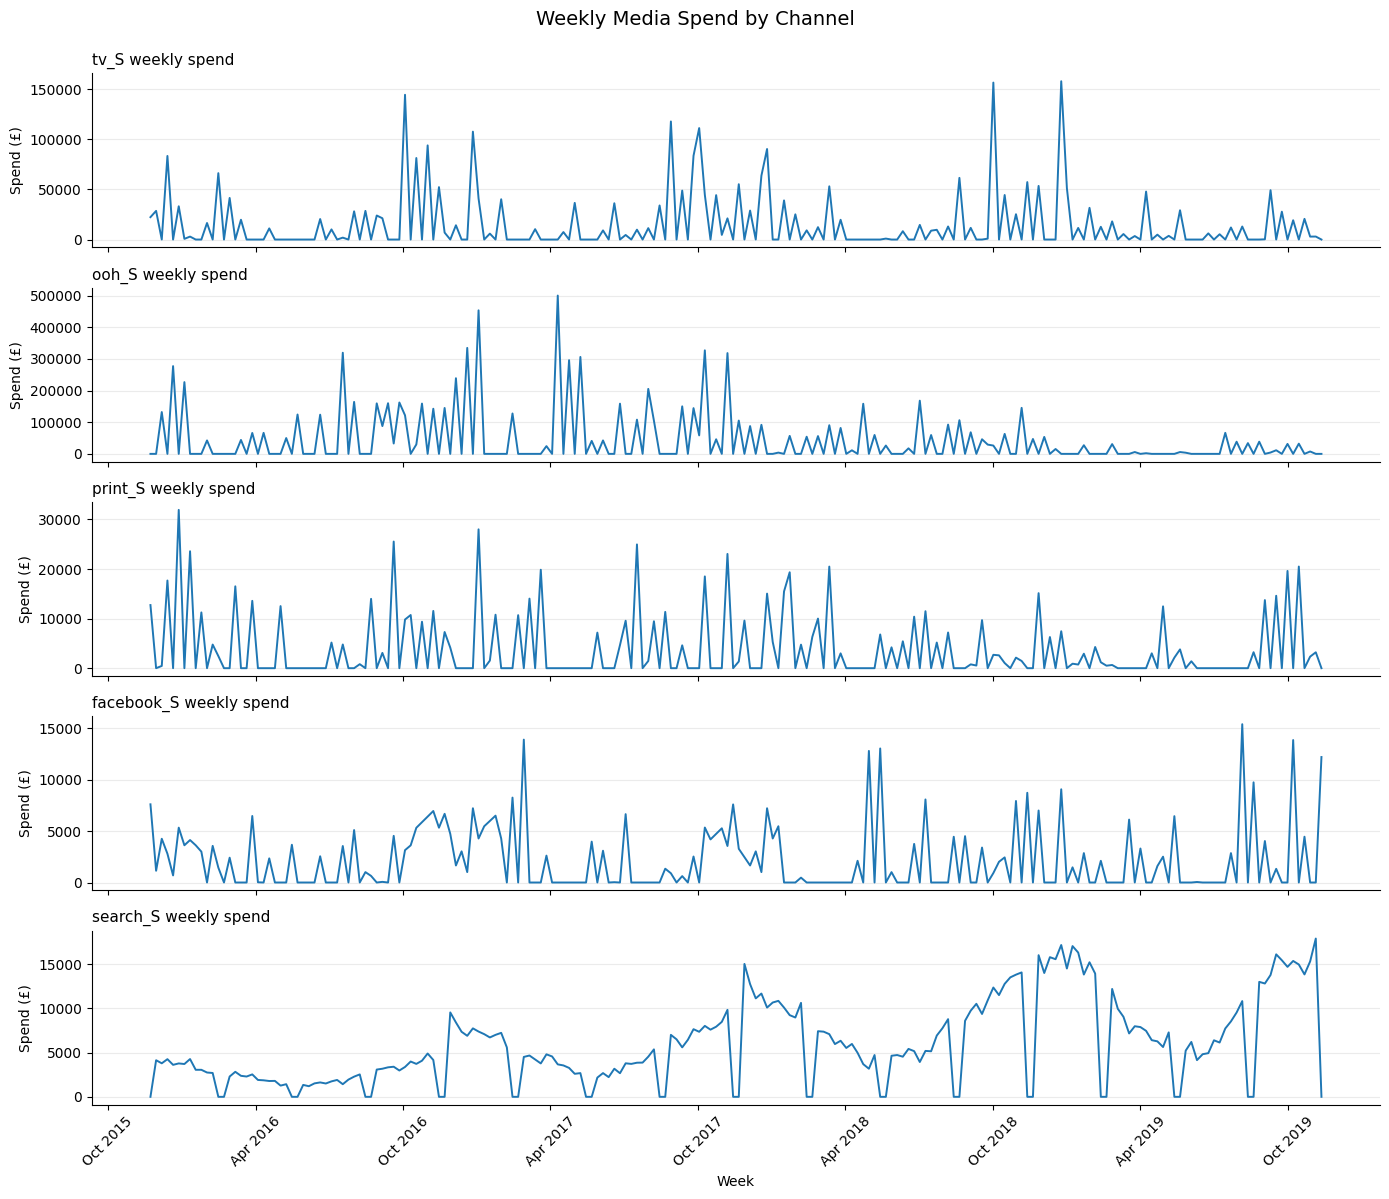

In [40]:
spend_long = df[[DATE] + MEDIA_SPEND_COLS].melt(
    id_vars=DATE, value_vars=MEDIA_SPEND_COLS, var_name='channel', value_name='spend'
)
spend_long['channel'] = pd.Categorical(spend_long['channel'], categories=MEDIA_SPEND_COLS, ordered=True)
spend_long = spend_long.sort_values([DATE, 'channel'])

fig, axes = plt.subplots(len(MEDIA_SPEND_COLS), 1, figsize=(14, 12), sharex=True)

for ax, channel in zip(axes, MEDIA_SPEND_COLS):
    channel_data = spend_long[spend_long['channel'] == channel]
    ax.plot(channel_data[DATE], channel_data['spend'], color='#1f77b4', linewidth=1.4)
    ax.set_title(f'{channel} weekly spend', loc='left', fontsize=11)
    ax.set_ylabel('Spend (£)')
    ax.grid(True, axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Week')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

fig.suptitle('Weekly Media Spend by Channel', fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig("../plots/eda_plots/media_spend_by_channel.png", dpi=150, bbox_inches='tight')
plt.show()

The first four media spends are highly flighted, while Search is almost always-on. In lieu of that, it’s industry standard to assume offline channels have long carryover, but because of the extreme gaps in this data, we will start with lower decay rates. We do this to ensure we aren't 'smearing' ad impact into weeks where sales might have naturally returned to baseline. 

We will only increase decay if these Stage 3 checks fail:
1. No autocorrelation -- are residuals independent week to week? (Durbin-Watson, should be close to 2)
2. Linearity -- do residuals vs fitted values look random with no pattern?

That way, the model is driven by the evidence in the wiggles of our data, not just a guess from a textbook.

| Channel Type | Decay Rate | Why? |
|---|---:|---|
| Search (Always-On) | 0.0 to 0.1 | Almost no carryover. You pay for the click, and the sale happens now. |
| Facebook (Flighted) | 0.1 to 0.2 | Social media feeds move fast. People usually act quickly or forget. |
| TV / Print / OOH | 0.2 to 0.3 | Even though these are "brand" channels, your plot is so bursty that you want to start low to see if the sales actually "linger." |

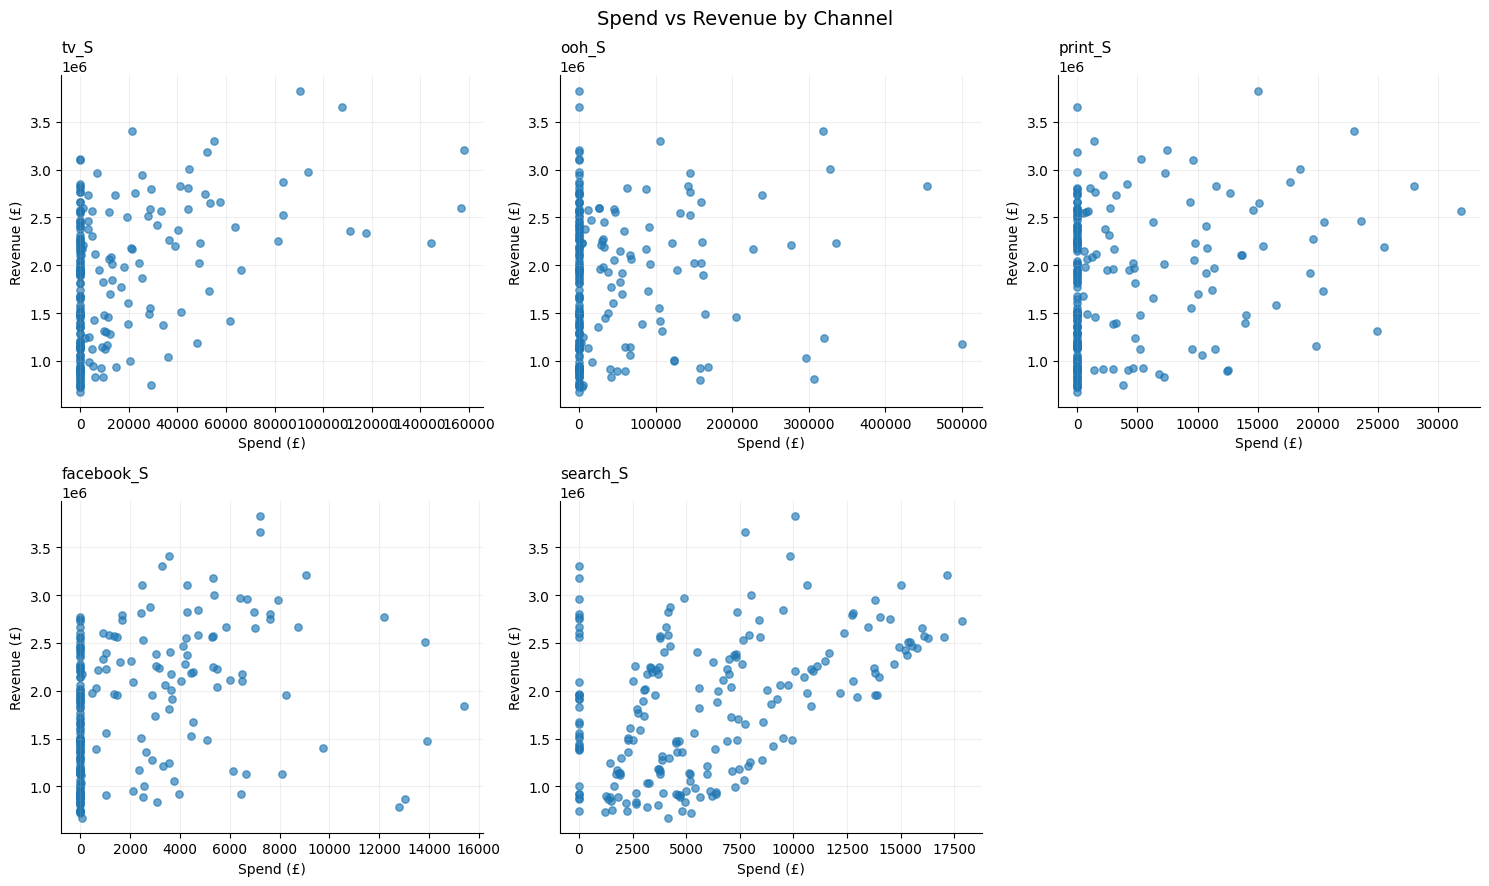

In [41]:
scatter_long = df[[TARGET] + MEDIA_SPEND_COLS].melt(
    id_vars=TARGET, value_vars=MEDIA_SPEND_COLS, var_name='channel', value_name='spend'
)
scatter_long['channel'] = pd.Categorical(scatter_long['channel'], categories=MEDIA_SPEND_COLS, ordered=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, channel in zip(axes, MEDIA_SPEND_COLS):
    channel_data = scatter_long[scatter_long['channel'] == channel]
    ax.scatter(channel_data['spend'], channel_data[TARGET], alpha=0.65, color='#1f77b4', s=28)
    ax.set_title(channel, loc='left', fontsize=11)
    ax.set_xlabel('Spend (£)')
    ax.set_ylabel('Revenue (£)')
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].axis('off')
fig.suptitle('Spend vs Revenue by Channel', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig("../plots/eda_plots/spend_vs_revenue_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

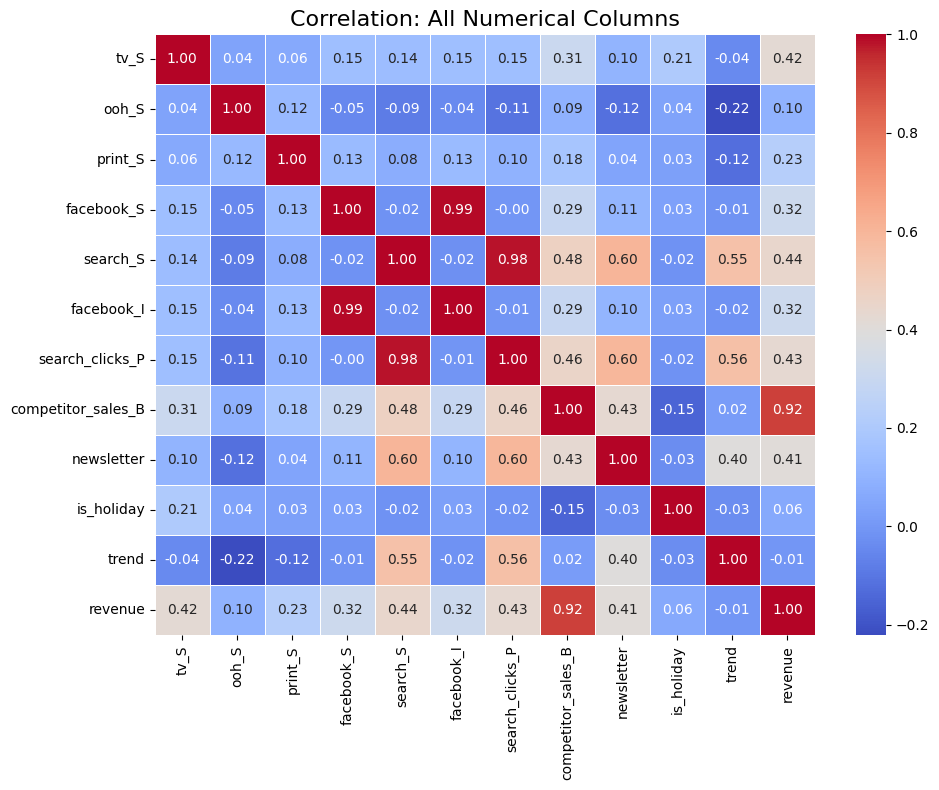

In [42]:
cols = ['tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S', 'facebook_I', 'search_clicks_P',
        'competitor_sales_B', 'newsletter', 'is_holiday', 'trend', 'revenue']
corr_matrix = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation: All Numerical Columns', fontsize=16)
plt.tight_layout()
plt.savefig("../plots/eda_plots/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

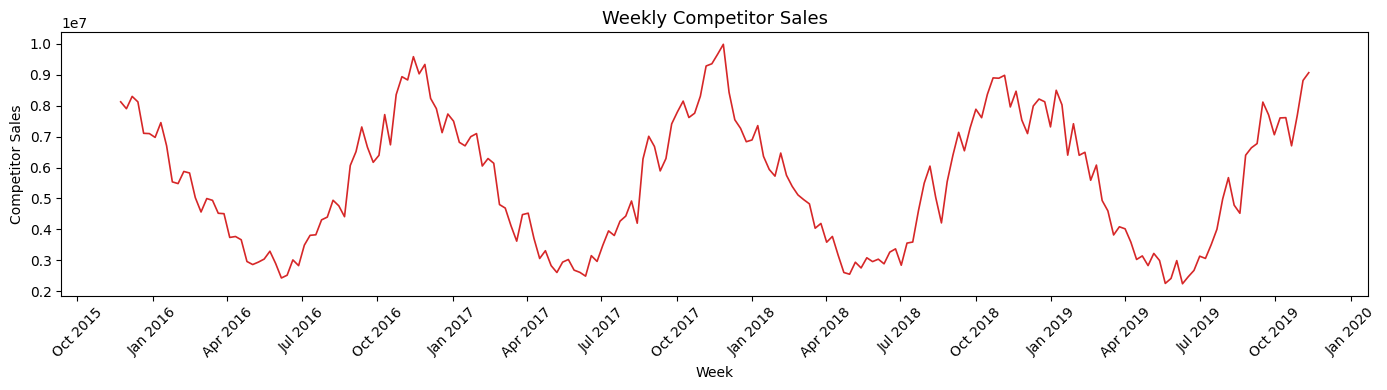

In [43]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df[DATE], df['competitor_sales_B'], linewidth=1.2, color='#d62728')
ax.set_title("Weekly Competitor Sales", fontsize=13)
ax.set_xlabel("Week")
ax.set_ylabel("Competitor Sales")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../plots/eda_plots/competitor_sales.png", dpi=150, bbox_inches='tight')
plt.show()

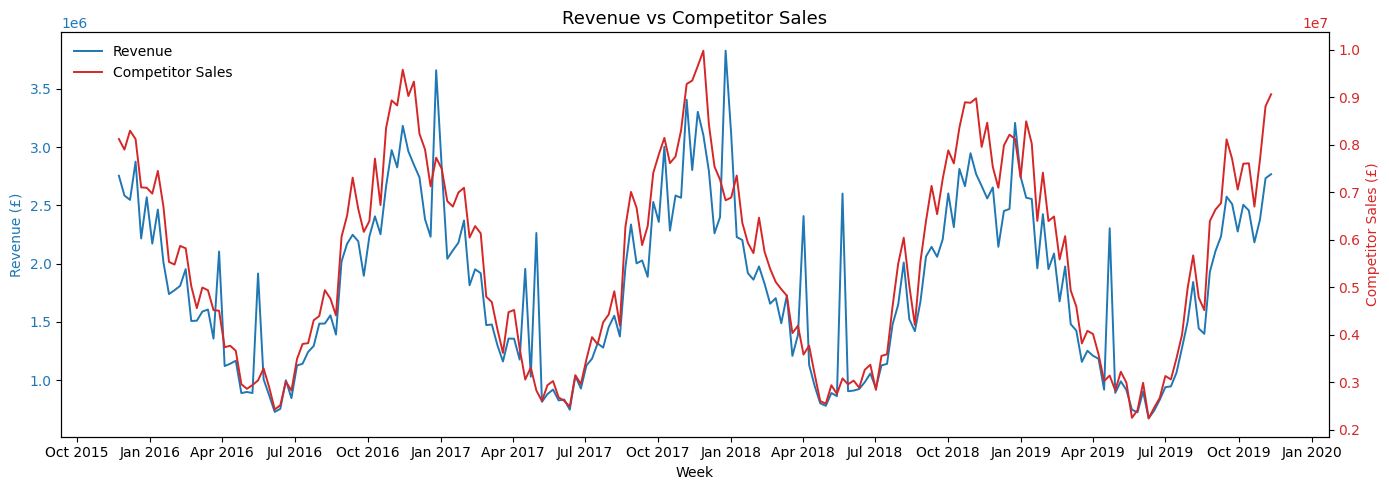

In [44]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(df[DATE], df['revenue'], linewidth=1.4, color='#1f77b4', label='Revenue')
ax1.set_ylabel('Revenue (£)', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

ax2 = ax1.twinx()
ax2.plot(df[DATE], df['competitor_sales_B'], linewidth=1.4, color='#d62728', label='Competitor Sales')
ax2.set_ylabel('Competitor Sales (£)', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')

ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper left')

ax1.set_title("Revenue vs Competitor Sales", fontsize=13)
ax1.set_xlabel("Week")

plt.tight_layout()
plt.savefig("../plots/eda_plots/revenue_vs_competitor.png", dpi=150, bbox_inches='tight')
plt.show()

In [45]:
from sklearn.linear_model import LinearRegression

vif_rows = []
vif_input = df[MEDIA_SPEND_COLS].copy()

for channel in MEDIA_SPEND_COLS:
    y = vif_input[channel].values
    X = vif_input.drop(columns=[channel]).values
    model = LinearRegression().fit(X, y)
    r2 = model.score(X, y)
    vif = np.inf if r2 >= 0.999999 else 1 / (1 - r2)
    partner_corr = vif_input.drop(columns=[channel]).corrwith(vif_input[channel]).abs().max()
    vif_rows.append({
        'channel': channel,
        'r_squared_on_other_channels': round(r2, 3),
        'vif': round(vif, 2),
        'max_abs_corr_with_another_channel': round(partner_corr, 2)
    })

vif_table = pd.DataFrame(vif_rows).sort_values('vif', ascending=False)
display(vif_table)

,channel,r_squared_on_other_channels,vif,max_abs_corr_with_another_channel
0,tv_S,0.046,1.05,0.15
3,facebook_S,0.045,1.05,0.15
2,print_S,0.043,1.04,0.13
4,search_S,0.037,1.04,0.14
1,ooh_S,0.032,1.03,0.12


All VIF scores sit between 1.03 and 1.05 — effectively 1, meaning the channels are spent almost entirely independently of each other. The model will be able to attribute effects to each channel separately without them interfering with one another. No collinearity issues to manage.

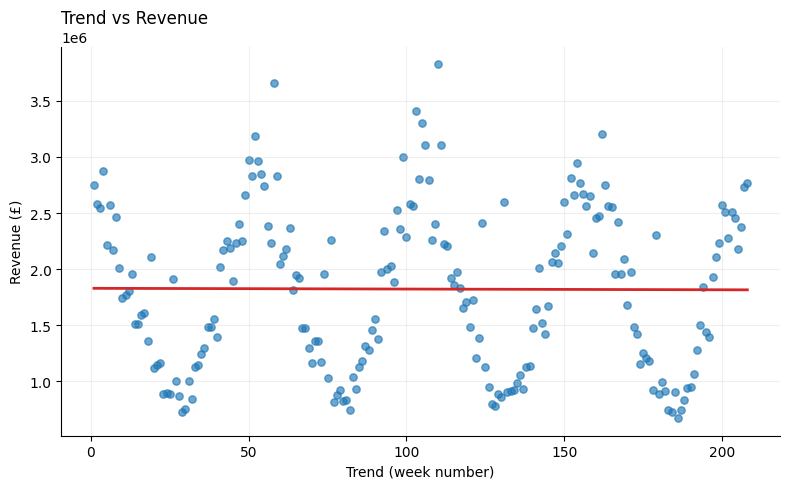

,trend,revenue
trend,1.00,-0.01
revenue,-0.01,1.00


In [46]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['trend'], df['revenue'], alpha=0.65, color='#1f77b4', s=28)
z = np.polyfit(df['trend'], df['revenue'], 1)
ax.plot(df['trend'], np.poly1d(z)(df['trend']), color='#d62728', linewidth=2)
ax.set_title('Trend vs Revenue', loc='left', fontsize=12)
ax.set_xlabel('Trend (week number)')
ax.set_ylabel('Revenue (£)')
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../plots/eda_plots/trend_vs_revenue.png", dpi=150, bbox_inches='tight')
plt.show()

display(df[['trend', 'revenue']].corr().round(2))

## ADF Test Output

An Augmented Dickey-Fuller check helps decide whether revenue is stationary enough to model in levels, or whether a log transform or differencing should be considered.

In [47]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['revenue'].dropna(), autolag='AIC')
adf_table = pd.DataFrame({
    'metric': ['adf_statistic', 'p_value', 'used_lag_count', 'n_obs'],
    'value': [adf_result[0], adf_result[1], adf_result[2], adf_result[3]]
})
critical_values = pd.DataFrame(adf_result[4], index=['critical_value']).T.reset_index().rename(columns={'index': 'significance_level'})
display(adf_table)
display(critical_values)

,metric,value
0,adf_statistic,-5.736818e+00
1,p_value,6.409872e-07
2,used_lag_count,1.400000e+01
3,n_obs,1.930000e+02


,significance_level,critical_value
0,1%,-3.464694
1,5%,-2.876635
2,10%,-2.574816


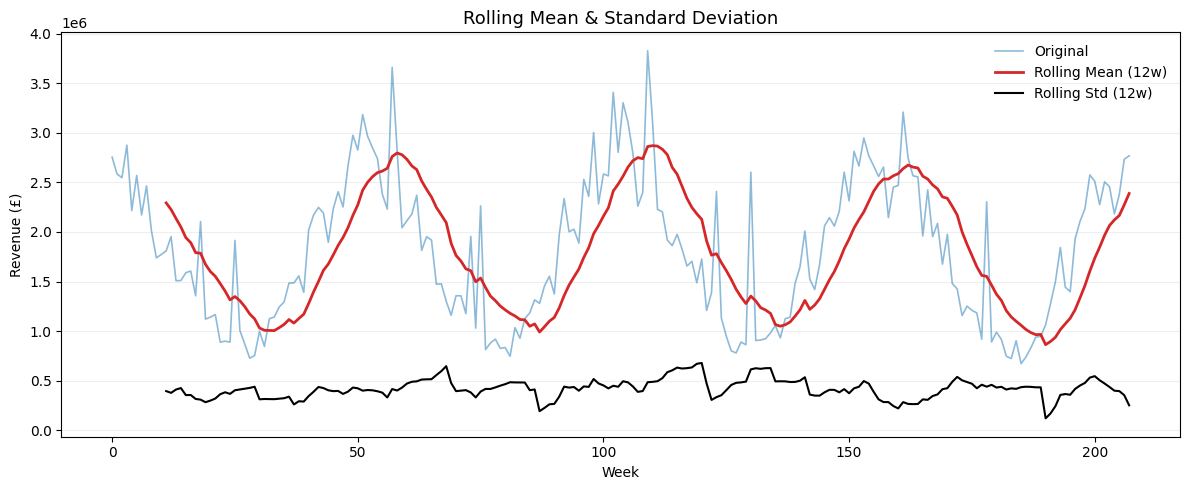

In [48]:
rolmean = df['revenue'].rolling(window=12).mean()
rolstd  = df['revenue'].rolling(window=12).std()

plt.figure(figsize=(12, 5))
plt.plot(df['revenue'].values, color='#1f77b4', label='Original', alpha=0.5, linewidth=1.2)
plt.plot(rolmean.values, color='#d62728', label='Rolling Mean (12w)', linewidth=2)
plt.plot(rolstd.values, color='black', label='Rolling Std (12w)', linewidth=1.5)
plt.title('Rolling Mean & Standard Deviation', fontsize=13)
plt.xlabel('Week')
plt.ylabel('Revenue (£)')
plt.legend(frameon=False)
plt.grid(True, axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig("../plots/eda_plots/rolling_mean_std.png", dpi=150, bbox_inches='tight')
plt.show()